In [ ]:
pip install catboost

In [ ]:
pip install sentence-transformers

In [ ]:
pip uninstall -y pyarrow

In [ ]:
pip install --no-cache-dir --force-reinstall pyarrow

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, Pool
from tqdm import tqdm, trange
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms as T
from torchvision import models
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
import os
from IPython.display import clear_output
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import OneHotEncoder

In [55]:
test_df = pd.read_parquet("test.parquet")
train_df = pd.read_parquet("train.parquet")
test_item_id = test_df["item_id"].values

Общая идея моего решения:

1. Взять 3 модели:
i. CatBoost на категориях, суб- и микрокатегориях + цене
ii. Нейронная сеть на эмбеддингах картинок (я решил их получать при помощи EfiicientNetB0, так как обучать пришлось на своем не очень мощном компьютере, 12 гб данных оч долго грузить), и на занятиях нам рассказывали про эту архитектуру как одну из самых эффективных в классе сверточных (а как visual transoformers работают я не знаю, поэтому их не использую).
iii. Нейронная сеть на эмбеддингах названий объявлений + их описаний, я выбрал e5 small по схожим соображениям, т.к. ее старшая версия находится в топе HuggingFace среди энкодеров для русского языка и она сравнительно маленькая
2. Дальше я думал просто брать среднее этих предсказаний, но решил поверх предсказаний этих трех моделей построить еще нейронную сеть, которая еще принимает на вход субкатегории, чтобы для каждой субкатегории сеть училась корретировать ошибки базовых моделей.

__Очистка данных__

Посмотрим что у нас в принципе происходит в данных для обучения:

In [56]:
train_df.describe()

,item_id,item_price,seller_id,buyer_id,real_weight,real_height,real_length,real_width
count,3.129080e+05,312908.000000,3.129080e+05,3.129080e+05,312908.000000,312908.000000,312908.000000,312908.000000
mean,1.067043e+06,2896.661904,1.124752e+06,1.201003e+06,1.691869,11.614749,33.134321,23.491592
std,6.059699e+05,6116.872498,6.930143e+05,6.898602e+05,19.957223,8.325673,204.112738,22.442816
min,4.000000e+00,1.000000,1.300000e+01,1.300000e+01,0.001000,1.000000,1.000000,1.000000
25%,5.444388e+05,500.000000,5.185470e+05,6.082150e+05,0.340000,6.000000,22.000000,16.000000
50%,1.072052e+06,1000.000000,1.089488e+06,1.200536e+06,0.690000,10.000000,32.000000,22.000000
75%,1.593838e+06,2650.000000,1.714254e+06,1.791919e+06,1.500000,15.000000,40.000000,30.000000
max,2.107277e+06,150000.000000,2.410939e+06,2.410986e+06,7090.000000,288.000000,111363.000000,11029.000000


In [57]:
train_df.sort_values(by="real_weight").tail(60)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
240024,1836483,2024-10-23,Б/у,5000.0,Личные вещи,Товары для детей и игрушки,Куклы и аксессуары,538886,348581,Дом мечты барби,"В идеальном состоянии, в комплекте куча мебели...",1836483.jpg,39.000,66.0,225.0,225.0
255943,1905430,2024-11-07,Б/у,20000.0,Для дома и дачи,Бытовая техника,Мелкая кухонная техника,417827,1257848,Духовой шкаф Weissgauff EOV 695 PDB/новый,Духовой шкаф Weissgauff EPV 695 PDB/новый\n\nЗ...,1905430.jpg,45.000,60.0,100.0,62.0
133692,1984185,2024-12-02,Новое,34500.0,Транспорт,Запчасти и аксессуары,Трансмиссия и привод,1491840,944010,Селектор (кулису)акпп 349010607r Renault,"Селектор КПП, кулиса КПП 349010607R\n\nКулиса ...",1984185.jpg,47.666,62.0,62.0,62.0
213052,325218,2024-12-25,Новое,25299.0,Транспорт,Запчасти и аксессуары,Для мото- и водного транспорта,277334,1551355,Компрессорный автохолодильник Alpicool U75 12/24,Компрессорный автохолодильник Alpicool U75 Ком...,325218.jpg,50.400,50.0,90.0,56.0
26862,382512,2024-07-11,Б/у,1500.0,Транспорт,Запчасти и аксессуары,Электрооборудование,1001075,57817,Электрический стеклоподъемник L/R BMW Е34,"Продаю стеклоподъемники, левый правый.",382512.jpg,60.000,20.0,100.0,30.0
156184,1739512,2024-12-22,Новое,32257.0,Электроника,Товары для компьютера,Корпуса,2390942,185290,Корпус asus ROG Strix Helios GX601 (новый),"Новый корпус, ни разу не использованный. Отпра...",1739512.jpg,65.856,49.0,84.0,80.0
306690,1548076,2024-12-04,Б/у,80000.0,Транспорт,Запчасти и аксессуары,Электрооборудование,834133,164018,Электрические пороги (автоматические) на LR De...,Продаю штатные выдвижные электрические пороги ...,1548076.jpg,66.000,33.0,200.0,50.0
181635,1641847,2024-11-03,Б/у,7000.0,Хобби и отдых,Спорт и отдых,Аксессуары для фитнеса,1262823,352249,Бодибар 6 кг,"Продаю 2 бодибаров неопреновых, вес одного 6 к...",1641847.jpg,89.700,36.0,372.0,45.0
271451,802294,2024-03-27,Новое,350.0,Электроника,Товары для компьютера,Аксессуары,1012298,991980,Сетка для микрофона,Сетки для микрофонов . Новые.\n\nВнутренний ди...,802294.jpg,95.000,1.0,40.0,30.0
269789,1722602,2024-12-03,Б/у,200.0,Транспорт,Запчасти и аксессуары,Кузов,1093522,2372105,Бампер передний Cruze,Бампер передний Chevrolet Cruze в чёрном цвете...,1722602.jpg,99.994,48.0,186.0,56.0


Судя по данным, кажется, что в большинстве объявлений с весом > 100 кг (кроме категории транспорт), люди перепутали граммы и кг, поэтому поделим эти значения на 1000.

In [58]:
train_df.sort_values(by="real_weight").head(5)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
13063,745132,2024-01-23,Новый,200.0,Личные вещи,Товары для детей и игрушки,Игрушки,1574079,2205716,Пакет из десткого мира лутбокс,здесь может быть все что угодно 🙂,745132.jpg,0.001,11.0,28.0,26.0
184148,1755549,2024-11-10,Отличное,500.0,Личные вещи,"Одежда, обувь, аксессуары",Кофты и футболки,1826915,1480946,Толстовка худи мужская Nike L,Худи мужская. Или женская если оверсайз .Состо...,1755549.jpg,0.001,9.0,40.0,15.0
302375,1143997,2024-09-03,Б/у,900.0,Личные вещи,Детская одежда и обувь,Куртки и пуховики,505450,465128,Полукомбинезон - брюки зимний,Брюки- полукомбинезон зимние Gusti. Мембрана....,1143997.jpg,0.001,10.0,36.0,27.0
210254,307936,2024-05-21,Б/у,1000.0,Личные вещи,Детская одежда и обувь,Свитеры и толстовки,49554,675310,"Шорты + футболки, пакетом",86-92,307936.jpg,0.001,7.0,25.0,16.0
270395,482106,2024-02-17,Новое,200.0,Хобби и отдых,Книги и журналы,Книги,815512,966054,Книга по экономике в комиксах,Экономикс. Книга в комиксах. Подходит хорошо и...,482106.jpg,0.001,4.0,34.0,22.0


In [59]:
len(train_df[train_df["real_weight"] <= 0.03])

4193

In [60]:
len(train_df)

312908

Много объявлений с весом 1 г, это явно ошибка. Так же есть немало объявлений с весом < 0.03 (30 г).Но сравнительно с размером датасета, их немного, поэтому можем позволить себе просто выкинуть их.

In [61]:
train_df = train_df[~(train_df["real_weight"] <= 0.05)] 
mask = (train_df["category_name"] != "Транспорт") & (train_df["real_weight"] >= 100)
train_df.loc[mask, "real_weight"] /= 1000

In [62]:
train_df.sort_values(by="real_weight").head(10)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
286074,1727380,2024-10-31,None,200.0,Личные вещи,Красота и здоровье,Парфюмерия,1402527,1617386,Духи Avon Incandessence инканденсанс,Продам духи инканденс :50мл-850р.,1727380.jpg,0.051,2.0,17.0,3.0
300213,2013552,2024-12-04,Новое,1300.0,Транспорт,Запчасти и аксессуары,Автосигнализации,1185500,1888848,Брелок сигнализации starline b92-94,Новый в пленках!,2013552.jpg,0.051,2.0,11.0,7.0
121722,361127,2024-09-15,Б/у,500.0,Для дома и дачи,Бытовая техника,Запчасти и аксессуары,2242344,1063638,Прессостат для стиральной машины HD505,Прессостат для стиральной машины Ariston Indes...,361127.jpg,0.051,8.0,11.0,10.0
79839,1841323,2024-10-23,Б/у,537.0,Личные вещи,Часы и украшения,Браслеты,1541520,1423720,Серебряный кулон,"Кулон, серебро, новый, не носился",1841323.jpg,0.051,3.0,16.0,8.0
234148,1158527,2024-11-02,Новый,650.0,Личные вещи,Детская одежда и обувь,Головные уборы,1085843,539520,Шапка шлем зимняя для девочки 40-42,новая 40-42,1158527.jpg,0.051,5.0,28.0,22.0
2248,1666636,2024-10-16,Б/у,215.0,Личные вещи,Товары для детей и игрушки,Игрушки для малышей,632046,2345006,Pigeon Игрушки погремушки прорезыватель pigeon,В отличном состоянии после одного ребенка. Фир...,1666636.jpg,0.051,3.0,21.0,18.0
32227,715421,2024-09-08,Б/у,1000.0,Личные вещи,Детская одежда и обувь,Куртки и пуховики,396250,719830,Куртки пакетом для девочки 80-86,"Продам куртки размер 80-86 и одну ветровку, ша...",715421.jpg,0.052,3.0,25.0,5.0
308500,1292289,2024-05-08,Новое,100.0,Электроника,Оргтехника и расходники,Канцелярия,2006973,1191503,Набор кистей для рисования ErichKrause,Новый набор кистей,1292289.jpg,0.052,20.0,20.0,20.0
16683,1984106,2024-11-27,Б/у,500.0,Личные вещи,Часы и украшения,Броши,336799,2329367,Янтарная брошь. СССР,Винтажная брошь на булавке из цельного природн...,1984106.jpg,0.052,5.0,9.0,7.0
73247,856258,2024-02-12,None,265.0,Личные вещи,Красота и здоровье,Макияж и маникюр,2141944,1956085,Clinique клиник ночная маска увлажняющая,"Почти полная, продаю т.к не пользуюсь\nДоставк...",856258.jpg,0.052,1.0,52.0,44.0


Теперь значения веса выглядят адекватно, можем смотреть другие столбцы.

В начале видели, что у некоторых объявлений длина/ширина/высота исчисляется километрами, это точно бред, посмотрим что происходит:

In [63]:
train_df.sort_values(by="real_height").tail(10)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
155592,588487,2024-11-16,Новое с биркой,300.0,Личные вещи,"Одежда, обувь, аксессуары","Джемперы, свитеры, кардиганы",557718,2061992,Водолазка женская тёплая новая,Водолазка тёплая р 42-48. Новая. К телу приятн...,588487.jpg,4.50,105.0,150.0,105.0
21117,1834023,2024-11-04,Новое с биркой,500.0,Личные вещи,"Одежда, обувь, аксессуары",Рюкзаки,1697859,626647,Новый классный рюкзак Гуси.Черный.Вышлю почтой,продам новый рюкзак Гуси.Вышлю почтой.,1834023.jpg,6.00,105.0,150.0,105.0
151541,1918352,2024-11-13,Новое,400.0,Для дома и дачи,Мебель и интерьер,Комплектующие,1836229,577504,Толкатель IKEA,Запечатанные и полностью комплектные. 7 шт в н...,1918352.jpg,15.00,105.0,150.0,105.0
186118,1950260,2024-11-18,Б/у,400.0,Хобби и отдых,Спорт и отдых,Товары для отдыха,1338135,21998,Сумка на руль для самоката,Продам сумку на руль для самоката/велосипеда. ...,1950260.jpg,12.00,105.0,150.0,105.0
3356,1811683,2024-11-15,Новое с биркой,2500.0,Личные вещи,"Одежда, обувь, аксессуары",Топы и футболки,883685,833017,Karl lagerfeld топ оригинал,Топ новый с биркой.\n\nРазмер в наличии s идёт...,1811683.jpg,0.60,105.0,150.0,105.0
238825,1826079,2024-10-29,Отличное,7400.0,Личные вещи,"Одежда, обувь, аксессуары",Пиджаки и костюмы,505189,738241,Фрак с жилетом,"Фрак с жилетом, шили на заказ, так ни разу и н...",1826079.jpg,6.00,105.0,150.0,105.0
249173,1875634,2024-10-27,Б/у,9500.0,Для дома и дачи,Бытовая техника,Очистители воздуха,1153747,267046,Мойка воздуха Venta lw15,Увлажнитель - мойка воздуха venta lw15. В отли...,1875634.jpg,11.07,108.0,150.0,120.0
197162,1661424,2024-11-12,Б/у,5400.0,Электроника,Оргтехника и расходники,"МФУ, копиры и сканеры",1093475,30370,Мфу лазерный Ricoh sp220 snw,"Хорошее рабочее состояние, без дефектов! Новый...",1661424.jpg,38.22,135.0,162.0,138.0
34669,1088814,2024-03-28,Б/у,800.0,Электроника,Фототехника,Оборудование и аксессуары,422671,1949683,Цифровая фоторамка view sonic,"Модель VFМ1036w-11Е\nВ хорошем состоянии, почт...",1088814.jpg,1.81,153.0,333.0,253.0
95915,1675102,2024-08-19,Б/у,100.0,Для дома и дачи,Посуда и товары для кухни,Товары для кухни,2178921,2391516,Хоз товары и тряпки,"Хоз товары, тряпки",1675102.jpg,15.81,288.0,437.0,321.0


In [64]:
train_df.sort_values(by="real_length").tail(20)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
190557,670743,2024-02-12,Б/у,200.0,Личные вещи,Товары для детей и игрушки,Игрушки,958665,154236,Набор для игры с пластилином Play Do,ЗАРЕЗЕРВИРОВАН!!!!Продаю машинки из набора Плэ...,670743.jpg,0.255,13.0,1010.0,14.0
302520,205578,2024-07-16,Б/у,990.0,Транспорт,Запчасти и аксессуары,Кузов,304822,388492,"Молдинг, накладка крыла передний правый Subaru","Артикул товара №56186\n\nМолдинг, накладка кры...",205578.jpg,0.210,10.0,1010.0,10.0
198735,1368296,2024-05-22,Хорошее,7000.0,Личные вещи,"Одежда, обувь, аксессуары",Спортивная обувь,1419302,2027964,Футбольные бутсы mizuno morelia neo,Привезли как подарок . Потренировался в них па...,1368296.jpg,0.700,23.0,1014.0,33.0
8669,454124,2024-01-14,Новое,525.0,Хобби и отдых,Спорт и отдых,Игры с мячом,1539619,1302494,Набор для гольфа,Продаётся набор для игры в гольф. Moscow duty...,454124.jpg,0.200,12.0,1016.0,12.0
286970,908902,2024-07-09,Б/у,3500.0,Хобби и отдых,Коллекционирование,Игры,784630,720198,Игры для sega mega drive 2 в коллекцию,"Цена указана за все, если хотите отдельно то ц...",908902.jpg,0.300,10.0,1020.0,20.0
41247,728952,2024-01-25,Отличное,1600.0,Личные вещи,"Одежда, обувь, аксессуары",Сумки,994566,2157785,Сумка женская y2k,Без торга. Сумка черная женская y2k. Небольшая...,728952.jpg,0.516,15.0,1020.0,30.0
280479,442021,2024-02-18,Б/у,1000.0,Для дома и дачи,Бытовая техника,Мелкая кухонная техника,2274841,517328,Соковыжималка moulinex 753,Ни разу не пользовались\nКак новая,442021.jpg,3.500,31.0,1022.0,32.0
192378,259405,2024-04-29,Хорошее,400.0,Личные вещи,"Одежда, обувь, аксессуары",Ботильоны,1979931,170325,Ботильоны искусственная кожа черные 37 ASOS,"Ботильоны демисезон ASOS, 37 размер, искусстве...",259405.jpg,1.030,14.0,1023.0,35.0
240188,89142,2024-06-28,Хорошее,3000.0,Личные вещи,"Одежда, обувь, аксессуары",Туфли,1106410,2119925,Туфли женские Versace,Туфли лодочки красного цвета использовались 3 ...,89142.jpg,0.600,30.0,1030.0,40.0
287110,821779,2024-02-21,Б/у,12800.0,Электроника,Ноутбуки,Ноутбуки,1068904,911744,Ноутбук i5 3337/ gforce 740m (toshiba),"Строит новый ssd на 256 gb, windows 10. Работа...",821779.jpg,3.395,15.0,1045.0,32.0


In [65]:
train_df.sort_values(by="real_width").tail(10)

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
251739,1864751,2024-10-22,Б/у,1300.0,Электроника,Аудио и видео,"Музыкальные центры, магнитолы",926817,23359,Музыкальный центр LG FFH-217AX,"музыкальной центр, диски барахлят, радио работ...",1864751.jpg,29.520,84.0,156.0,141.0
26994,1945107,2024-11-13,Б/у,600.0,Личные вещи,Товары для детей и игрушки,Товары для купания,1100433,2044165,Ванночка для купания складная с гамаком,"Бронь! \n\nПродаю складную детскую ванну, с га...",1945107.jpg,6.300,18.0,228.0,150.0
286287,1884059,2024-10-28,Б/у,3500.0,Хобби и отдых,Спорт и отдых,Настольные игры,1372519,22841,Подставка для настольного хоккея stiga,"Подставка для хоккея Stiga, есть регулировка п...",1884059.jpg,11.700,21.0,285.0,156.0
46306,993462,2024-11-12,Новый,9190.0,Личные вещи,Товары для детей и игрушки,Конструкторы,206224,413127,Конструктор playmobil 9462 City Action Пожарна...,"Уценка, нетоварный вид коробки\n\nДаже в самом...",993462.jpg,10.362,33.0,198.0,165.0
307037,1745944,2024-10-26,Б/у,540.0,Личные вещи,Товары для детей и игрушки,Постельные принадлежности,1400307,934415,Матрас для детей 120 60,Матрасик \nПользовались 3-4 Месяца. \n120*60,1745944.jpg,3.000,30.0,330.0,174.0
240024,1836483,2024-10-23,Б/у,5000.0,Личные вещи,Товары для детей и игрушки,Куклы и аксессуары,538886,348581,Дом мечты барби,"В идеальном состоянии, в комплекте куча мебели...",1836483.jpg,39.000,66.0,225.0,225.0
34669,1088814,2024-03-28,Б/у,800.0,Электроника,Фототехника,Оборудование и аксессуары,422671,1949683,Цифровая фоторамка view sonic,"Модель VFМ1036w-11Е\nВ хорошем состоянии, почт...",1088814.jpg,1.810,153.0,333.0,253.0
95915,1675102,2024-08-19,Б/у,100.0,Для дома и дачи,Посуда и товары для кухни,Товары для кухни,2178921,2391516,Хоз товары и тряпки,"Хоз товары, тряпки",1675102.jpg,15.810,288.0,437.0,321.0
267680,961397,2024-05-23,Б/у,5300.0,Транспорт,Запчасти и аксессуары,Тормозная система,371963,1165394,Диск тормозной ауди Q7 4M 4M0615301AB перед,4M0615301AB\r\nОРИГИНАЛЬНЫЙ 100%!\r\nMade in G...,961397.jpg,23.800,14.0,365.0,365.0
180033,216891,2024-01-11,None,370.0,Личные вещи,Красота и здоровье,Средства для волос,1345411,1467631,Schwarzkopf professional Кондиционер для волос,Кондиционер для волос PEPTIDE REPAIR rescue дл...,216891.jpg,0.560,1.0,21789.0,11029.0


Есть наблюдения, у которых неадекватно большая длина или высота, посмотрим сколько их, и можем ли мы позволить себе убрать их.
Так же посмотрим, сколько наблюдений с очень маленькими измерениями (1 см), и снова можем ли мы позволить себе их просто выкинуть.

In [66]:
len(train_df[(train_df["real_height"] > 200) | (train_df["real_length"] > 300) | (train_df["real_width"] > 170)])  

36

In [67]:
len(train_df[(train_df["real_height"] <= 1) | (train_df["real_length"] <= 1) | (train_df["real_width"] <= 1)]) 

39487

Их многовато, больше 10% датасета, посмотрим подробнее что тут происходит.

In [68]:
train_df[train_df["real_height"] == 1]

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
14,1121886,2024-05-10,Хорошее,2500.0,Личные вещи,"Одежда, обувь, аксессуары",Плащи и тренчи,1095427,645775,Плащ женский marella (max mara),"женский плащ marella (max mara), размер 48, цв...",1121886.jpg,0.655,1.0,46.0,36.0
16,1531359,2024-07-06,Б/у,2200.0,Хобби и отдых,Спорт и отдых,Ролики и скейтбординг,1079414,2068410,Дека для скейтборда 8.5,Дека Абсурд для скейтборда 8.5х32.5. Шкурка Юн...,1531359.jpg,1.400,1.0,46.0,36.0
21,815387,2024-04-29,Отличное,1500.0,Личные вещи,"Одежда, обувь, аксессуары",Пиджаки и костюмы,1734631,871689,Джинсовый пиджак 48-50,Продам пиджак джинсовый в отличном состоянии о...,815387.jpg,0.830,1.0,46.0,36.0
32,1147948,2024-04-27,Отличное,4999.0,Личные вещи,"Одежда, обувь, аксессуары",Ботинки и полуботинки,1510498,1454552,Трекинговые ботинки женские 38,Ботинки трекинговые надевались в один поход. ...,1147948.jpg,1.075,1.0,46.0,36.0
40,881248,2024-04-03,Отличное,400.0,Личные вещи,"Одежда, обувь, аксессуары",Топы и футболки,1654561,826198,Футболка женская бу 5XL забронировано,"Кофточка на лето, размер 62, с открытыми плеча...",881248.jpg,0.220,1.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312870,1143936,2024-04-20,Новый,3511.0,Личные вещи,Детская одежда и обувь,Кроссовки и кеды,816255,1393176,Кроссовки Pablosky р.33,"Кроссовки Pablosky р.33, кожа на коже, новые, ...",1143936.jpg,0.495,1.0,40.0,30.0
312871,647033,2024-02-15,None,1750.0,Личные вещи,Красота и здоровье,Парфюмерия,1261353,666098,Духи liu jo оригинал,"Духи Liu Jo,подарили, два пшика, не мой аромат...",647033.jpg,0.435,1.0,52.0,44.0
312879,347047,2024-04-24,Новое,20000.0,Транспорт,Запчасти и аксессуары,Набор автомобилиста,69917,1273290,Комплект доя перекачки дизельного топлива,PIUSIBOX 12 V Basic – заправочное оборудование...,347047.jpg,9.450,1.0,46.0,36.0
312885,616132,2024-02-18,Отличное,2000.0,Личные вещи,"Одежда, обувь, аксессуары",Брюки,1264663,916696,Вельветовые брюки женские бордовые noom 46-48р,"Продам вельветовые брюки в отличном состоянии,...",616132.jpg,0.446,1.0,40.0,30.0


Много вещей с высотой 1, обычно это одежда, или какие-то +- плоские вещи, оставим их, скорее всего людям лень измерять высоту, если она не важна или на порядок меньше других измерений, вероятно в тестовой выборке будет так же (хотя в реальной задаче лучше бы все таки вручную подчистить данные или хотя бы внимательнее изучить данные, и например заменить 1 на другое число, которое лучше всего описывает в реальности высоту в категории/субкатегории, мб дальше так и сделаю).

In [69]:
train_df[train_df["real_length"] == 1]

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
1993,1406396,2024-08-29,Б/у,1000.0,Для дома и дачи,Мебель и интерьер,Люстры и потолочные светильники,46521,765214,Светильники IKEA oleby (4 шт),"Светильники Улеби Икеа, 302.036.90. \n2 шт без...",1406396.jpg,0.250,1.0,1.0,1.0
2097,184109,2024-09-11,Новый,800.0,Личные вещи,Товары для детей и игрушки,Мягкие игрушки,143984,820592,Зайчик вязаный,Связано с любовью ❤️,184109.jpg,0.210,1.0,1.0,1.0
2693,1458969,2024-06-19,Б/у,679.0,Электроника,Телефоны,Мобильные телефоны,1855465,1656057,"Nokia 3 Dual sim, 2/16 ГБ","Смартфон полностью рабочий, нет лотка под флеш...",1458969.jpg,0.170,1.0,1.0,1.0
2724,1569720,2024-07-13,Новое,100.0,Транспорт,Запчасти и аксессуары,Тюнинг,966062,1558729,Тумблер т1,10штук,1569720.jpg,0.370,1.0,1.0,1.0
3999,387298,2024-11-16,None,950.0,Личные вещи,Красота и здоровье,Парфюмерия,255288,646890,Туалетная вода Ermenegildo Zegna indian spice,🎾В России оригинал не купить!!!\n\nIndian Spic...,387298.jpg,0.380,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310408,1775840,2024-10-25,None,600.0,Личные вещи,Красота и здоровье,Макияж и маникюр,1603871,1261807,Ilia fullest volumizing mascara 4ml,"Новый , ОРИГИНАЛ!\n\nЦена за штуку\n\nАвито до...",1775840.jpg,0.470,1.0,1.0,1.0
310719,2105843,2024-12-29,Новое,540.0,Хобби и отдых,Коллекционирование,Модели,1708276,875484,Кастом колеса для Supra + декали Eclipse для В...,Колеса и декали для Влада,2105843.jpg,0.200,1.0,1.0,1.0
311015,1782361,2024-11-25,Новое,300.0,Электроника,Телефоны,Чехлы и плёнки,917378,2398742,Чехол 2шт стеклянный для samsung galaxy s20,Продаю 2 новых чехла.Пока шли продал телефон....,1782361.jpg,0.230,1.0,1.0,1.0
311140,65795,2024-10-09,Новое,50.0,Электроника,Телефоны,Чехлы и плёнки,1116400,289995,Чехлы для Samsung Galaxy A40 и универсальные,"Верхний ряд универсальные, нижний для Самсунг ...",65795.jpg,0.190,1.0,1.0,1.0


In [70]:
train_df[train_df["real_width"] == 1]

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
66,1016885,2024-03-22,Б/у,300.0,Транспорт,Запчасти и аксессуары,Для мототехники,2331450,1154907,Крыльчатки обдува скутер,Крыльчатки хонда дио\n\nЦена за еденицу \n\n⚙️...,1016885.jpg,0.400,1.0,2.0,1.0
629,1207513,2024-07-10,Новое,900.0,Электроника,Телефоны,Чехлы и плёнки,1444080,556103,Чехол книжка на samsung m21,Чехол книжка на samsung m21. Заказывал на свой...,1207513.jpg,0.170,1.0,2.0,1.0
871,1494339,2024-07-14,Хорошее,600.0,Личные вещи,"Одежда, обувь, аксессуары",Шлёпанцы и сланцы,1071609,100996,"Вьетнамки, шлепанцы через палец Zara 38","Состояние хорошее, для удобства ходьбы наклеил...",1494339.jpg,0.520,1.0,2.0,1.0
950,1903307,2024-11-02,Б/у,500.0,Электроника,Товары для компьютера,Корпуса,1211019,626948,Переходная заглушка без кнопки,Только заглушка,1903307.jpg,0.120,1.0,2.0,1.0
953,354621,2024-09-05,Б/у,1000.0,Транспорт,Запчасти и аксессуары,Тормозная система,2048443,2185119,Кожух тормозного диска задний левый Kia Optima TF,Кожух тормозного диска Kia Optima TF 2.0 2012 ...,354621.jpg,1.790,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310719,2105843,2024-12-29,Новое,540.0,Хобби и отдых,Коллекционирование,Модели,1708276,875484,Кастом колеса для Supra + декали Eclipse для В...,Колеса и декали для Влада,2105843.jpg,0.200,1.0,1.0,1.0
311015,1782361,2024-11-25,Новое,300.0,Электроника,Телефоны,Чехлы и плёнки,917378,2398742,Чехол 2шт стеклянный для samsung galaxy s20,Продаю 2 новых чехла.Пока шли продал телефон....,1782361.jpg,0.230,1.0,1.0,1.0
311140,65795,2024-10-09,Новое,50.0,Электроника,Телефоны,Чехлы и плёнки,1116400,289995,Чехлы для Samsung Galaxy A40 и универсальные,"Верхний ряд универсальные, нижний для Самсунг ...",65795.jpg,0.190,1.0,1.0,1.0
311632,918896,2024-02-24,Б/у,600.0,Личные вещи,Часы и украшения,Наручные или карманные,696100,494396,Часы наручные на запчасти,"Часы наручные tissot, daniel klein. Будут рабо...",918896.jpg,0.395,1.0,1.0,1.0


В случае если другие измерения равны 1, то тут точно ошибка в объявлении (т.к. длина >= ширина >= высота), просто удалим их, их всего 1300.

In [71]:
mask = (
    (train_df["real_height"] > 200)
    | (train_df["real_length"] > 300)
    | (train_df["real_width"] > 170)
    | (train_df["real_length"] == 1)
    | (train_df["real_width"] == 1)
)

train_df = train_df.loc[~mask].reset_index(drop=True)

Заменим значения real_height = 1 на средние для этой микрокатегории (средние будем считать, исключая значения 1)

In [72]:
counts_by_microcat = train_df[train_df["real_height"] != 1].groupby("microcat_name")["real_height"].count()
print(min(counts_by_microcat), counts_by_microcat.mean())

27 743.9693593314763


Данных достаточно в каждой микрокатегории, можем считать средние по ней

In [73]:
means_by_microcat = train_df[train_df["real_height"] != 1].groupby("microcat_name")["real_height"].mean()

mask = train_df["real_height"] == 1
train_df_filtered = train_df.copy()
train_df_filtered.loc[mask, "real_height"] = (
    train_df.loc[mask, "microcat_name"]
    .map(means_by_microcat)
)

In [74]:
train_df

,item_id,order_date,item_condition,item_price,category_name,subcategory_name,microcat_name,seller_id,buyer_id,title,description,image_name,real_weight,real_height,real_length,real_width
0,185689,2024-09-27,Б/у,3000.0,Транспорт,Запчасти и аксессуары,Салон,1942218,1935418,Ручка АКПП mercedes w203 avangarde,Ручка рычаг акпп на Мерседес В203 mercedes w20...,185689.jpg,0.370,10.0,23.0,19.0
1,1914373,2024-11-07,Новое с биркой,5990.0,Личные вещи,"Одежда, обувь, аксессуары",Зимние куртки и пуховики,2164034,1753243,Пуховик Moncler голубой (52 размер),Объявление для заказа 📲\n\nАвито доставка 🚚\n\...,1914373.jpg,2.486,14.0,37.0,24.0
2,361626,2024-12-15,Новое,1200.0,Транспорт,Запчасти и аксессуары,Двигатель,621511,1233378,Запчасти на ford фокус1,"Опора задняя,двигатель w тигуан 1,4 150 б.у",361626.jpg,0.640,7.0,23.0,18.0
3,534927,2024-01-20,Б/у,13000.0,Электроника,"Игры, приставки и программы",Игровые приставки и аксессуары,998450,1082324,Ps3 cechc 08 скальпирована HEN(полностью испра...,"В комплекте приставка, провода(зарядка, питани...",534927.jpg,7.100,20.0,35.0,20.0
4,199043,2024-07-28,Отличное,300.0,Личные вещи,"Одежда, обувь, аксессуары","Джемперы, свитеры, кардиганы",528098,477834,Свитер трикотаж 44 р-р Reserved,Свитер Pull&Bear (пул энд бир)\n44 размер\nНад...,199043.jpg,0.400,7.0,23.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305469,1156951,2024-04-10,Б/у,600.0,Личные вещи,Красота и здоровье,Приборы и аксессуары,274684,632732,Массажер электрический Relax&Tone,"Массажеры электрические Relax & Spin Tone, пол...",1156951.jpg,1.000,14.0,26.0,26.0
305470,2095493,2024-12-23,Новое,2500.0,Личные вещи,Красота и здоровье,Медицинские изделия,407661,732373,Матрас противопролежневый трубчатый armed,"Новый, только открывался , надувался, но не по...",2095493.jpg,5.956,21.0,44.0,34.0
305471,218757,2024-02-04,Новое,1900.0,Транспорт,Запчасти и аксессуары,Защита и декор,528561,1929284,Спойлер /KIA023/ Kia Optima (2010-13),"Спойлер /KIA023/ (под покраску), для а/м: Kia ...",218757.jpg,2.280,11.0,122.0,30.0
305472,1470684,2024-06-18,Отличное,500.0,Личные вещи,"Одежда, обувь, аксессуары",Туфли,223938,1254267,Туфли Carnaby 40 размер,"Продам туфли Carnaby, натуральная кожа внутри ...",1470684.jpg,0.760,11.0,29.0,14.0


Потеряли всего около 8к наблюдений (<3%), теперь эти данные можно использовать для обучения.

Выбросим колонки, которые никак, кроме случайной связи в данных, не могут предсказывать нужные нам параметры.

In [75]:
train_df_filtered = train_df_filtered.drop(columns=["item_id", "order_date", "seller_id", "buyer_id"])
train_df = train_df.drop(columns=["item_id", "order_date", "seller_id", "buyer_id"])
test_df = test_df.drop(columns=["item_id", "order_date", "seller_id", "buyer_id"])

In [76]:
train_df_filtered

,item_condition,item_price,category_name,subcategory_name,microcat_name,title,description,image_name,real_weight,real_height,real_length,real_width
0,Б/у,3000.0,Транспорт,Запчасти и аксессуары,Салон,Ручка АКПП mercedes w203 avangarde,Ручка рычаг акпп на Мерседес В203 mercedes w20...,185689.jpg,0.370,10.0,23.0,19.0
1,Новое с биркой,5990.0,Личные вещи,"Одежда, обувь, аксессуары",Зимние куртки и пуховики,Пуховик Moncler голубой (52 размер),Объявление для заказа 📲\n\nАвито доставка 🚚\n\...,1914373.jpg,2.486,14.0,37.0,24.0
2,Новое,1200.0,Транспорт,Запчасти и аксессуары,Двигатель,Запчасти на ford фокус1,"Опора задняя,двигатель w тигуан 1,4 150 б.у",361626.jpg,0.640,7.0,23.0,18.0
3,Б/у,13000.0,Электроника,"Игры, приставки и программы",Игровые приставки и аксессуары,Ps3 cechc 08 скальпирована HEN(полностью испра...,"В комплекте приставка, провода(зарядка, питани...",534927.jpg,7.100,20.0,35.0,20.0
4,Отличное,300.0,Личные вещи,"Одежда, обувь, аксессуары","Джемперы, свитеры, кардиганы",Свитер трикотаж 44 р-р Reserved,Свитер Pull&Bear (пул энд бир)\n44 размер\nНад...,199043.jpg,0.400,7.0,23.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...
305469,Б/у,600.0,Личные вещи,Красота и здоровье,Приборы и аксессуары,Массажер электрический Relax&Tone,"Массажеры электрические Relax & Spin Tone, пол...",1156951.jpg,1.000,14.0,26.0,26.0
305470,Новое,2500.0,Личные вещи,Красота и здоровье,Медицинские изделия,Матрас противопролежневый трубчатый armed,"Новый, только открывался , надувался, но не по...",2095493.jpg,5.956,21.0,44.0,34.0
305471,Новое,1900.0,Транспорт,Запчасти и аксессуары,Защита и декор,Спойлер /KIA023/ Kia Optima (2010-13),"Спойлер /KIA023/ (под покраску), для а/м: Kia ...",218757.jpg,2.280,11.0,122.0,30.0
305472,Отличное,500.0,Личные вещи,"Одежда, обувь, аксессуары",Туфли,Туфли Carnaby 40 размер,"Продам туфли Carnaby, натуральная кожа внутри ...",1470684.jpg,0.760,11.0,29.0,14.0


In [77]:
train_df_filtered.columns

Index(['item_condition', 'item_price', 'category_name', 'subcategory_name',
       'microcat_name', 'title', 'description', 'image_name', 'real_weight',
       'real_height', 'real_length', 'real_width'],
      dtype='object')

In [78]:
train_df.to_parquet("train_df_partially_filtered.parquet")

__Catboost как baseline для бенчмарка__

In [37]:
cat_features = ['item_condition', 'category_name', 'subcategory_name',
       'microcat_name']
targets = list(train_df_filtered.columns)[-4:]

X_boosting = train_df_filtered[['item_price'] + cat_features].copy()
y = train_df_filtered[targets].copy()
y[targets] = np.log1p(y[targets])

In [31]:
params_grid = {
    "depth": [6, 8],
    "iterations": [1000]
}
X_boosting[cat_features] = X_boosting[cat_features].fillna("NA").astype(str)
cat_idx = [X_boosting.columns.get_loc(c) for c in cat_features]
models = []

# grid search для веса
pool = Pool(X_boosting, label=y[targets[0]], cat_features=cat_idx)
model = CatBoostRegressor(loss_function="MAE", eval_metric="MAE", verbose=False, random_seed=42)
model.grid_search(params_grid, pool, cv=3, verbose=False, plot=False)
best_w_params = model.get_params()
model = CatBoostRegressor(**best_w_params)
model.fit(pool)
models.append(model)

# grid search один раз для параметров д/ш/в
pool = Pool(X_boosting, label=y[targets[1]], cat_features=cat_idx)
model = CatBoostRegressor(loss_function="MAE", eval_metric="MAE", verbose=False, random_seed=42)
model.grid_search(params_grid, pool, cv=3, verbose=False, plot=False)
best_params = model.get_params()


for t in tqdm(targets[1:]):
    train_pool = Pool(X_boosting, label=y[t], cat_features=cat_idx)
    model = CatBoostRegressor(**best_params)
    model.fit(train_pool)
    models.append(model)


bestTest = 0.2926322831
bestIteration = 999


bestTest = 0.2907146448
bestIteration = 999

Training on fold [0/3]

bestTest = 0.2907023329
bestIteration = 998

Training on fold [1/3]

bestTest = 0.2921488552
bestIteration = 998

Training on fold [2/3]

bestTest = 0.2917970162
bestIteration = 999


bestTest = 0.3230298798
bestIteration = 999


bestTest = 0.3221062341
bestIteration = 998

Training on fold [0/3]

bestTest = 0.3229755409
bestIteration = 999

Training on fold [1/3]

bestTest = 0.3216618798
bestIteration = 999

Training on fold [2/3]

bestTest = 0.3230761428
bestIteration = 999



100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [11:24<00:00, 228.15s/it]


__Делаем предикты простым катбустом__

In [36]:
print(best_w_params, best_params)

{'loss_function': 'MAE', 'random_seed': 42, 'verbose': False, 'eval_metric': 'MAE', 'depth': 8, 'iterations': 1000} {'loss_function': 'MAE', 'random_seed': 42, 'verbose': False, 'eval_metric': 'MAE', 'depth': 8, 'iterations': 1000}


In [47]:
X_test = test_df[['item_price'] + cat_features].copy()
X_test[cat_features] = X_test[cat_features].fillna("NA").astype(str)
cat_idx = [X_test.columns.get_loc(c) for c in cat_features]

test_pool = Pool(X_test, cat_features=cat_idx)

preds = {}
for target, model in zip(targets, models):
    preds[target] = np.expm1(model.predict(test_pool))
    
result = pd.DataFrame({
    "item_id": test_item_id,
    "weight": preds["real_weight"].astype(float),
    "height": preds["real_height"].astype(float),
    "length": preds["real_length"].astype(float),
    "width": preds["real_width"].astype(float),
})
result.to_csv("predictions/boosting_predictions.csv", index=False)

MAE на степике ~0.348.

На всякий случай попробуем откатить изменения датасета (где меняли 1 в д/ш/в), может на степике тоже шумные данные в валидации. 

In [25]:
best_params = {'loss_function': 'MAE', 'random_seed': 42, 'verbose': False, 'eval_metric': 'MAE', 'depth': 8, 'iterations': 1000}

In [26]:
cat_features = ['item_condition', 'category_name', 'subcategory_name',
       'microcat_name']
targets = list(train_df.columns)[-4:]

X_boosting = train_df[['item_price'] + cat_features].copy()
y = train_df[targets].copy()
y[targets] = np.log1p(y[targets])
X_boosting[cat_features] = X_boosting[cat_features].fillna("NA").astype(str)
cat_idx = [X_boosting.columns.get_loc(c) for c in cat_features]
models = []

In [39]:
pool = Pool(X_boosting, label=y[targets[0]], cat_features=cat_idx)
model = CatBoostRegressor(**best_params)
model.fit(pool)
models.append(model)

for t in tqdm(targets[1:]):
    train_pool = Pool(X_boosting, label=y[t], cat_features=cat_idx)
    model = CatBoostRegressor(**best_params)
    model.fit(train_pool)
    models.append(model)
X_test = test_df[['item_price'] + cat_features].copy()
X_test[cat_features] = X_test[cat_features].fillna("NA").astype(str)
cat_idx = [X_test.columns.get_loc(c) for c in cat_features]

test_pool = Pool(X_test, cat_features=cat_idx)

preds = {}
for target, model in zip(targets, models):
    preds[target] = np.expm1(model.predict(test_pool))
    
result = pd.DataFrame({
    "item_id": test_item_id,
    "weight": preds["real_weight"].astype(float),
    "height": preds["real_height"].astype(float),
    "length": preds["real_length"].astype(float),
    "width": preds["real_width"].astype(float),
})
result.to_csv("predictions/boosting_predictions_unfiltered.csv", index=False)

100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [12:38<00:00, 252.73s/it]


На степике теперь 0.3404, поэтому будем использовать неочищенный датасет

__ПОЛУЧАЕМ ЭМБЕДДИНГИ ДЛЯ ДАЛЬНЕЙШЕГО ОБУЧЕНИЯ__

__КАРТИНКИ__

Получение эмбеддингов при помощи EfficientNetB0

In [43]:
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

class ImagesDataset(Dataset):
    def __init__(self, df, path = 'train'):
        self.df = df
        self.path = path
        self.norm = T.Normalize(MEAN, STD)
        self.resize = T.Resize((224, 224)) 
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_name']
        image = read_image(os.path.join(self.path, img_name))  
        
        image = self.norm(self.resize(image.float() / 255.))
        return image

In [44]:
class ImageEmbedder(nn.Module):
    def __init__(self):
        super(ImageEmbedder, self).__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.model = nn.Sequential(*(list(models.efficientnet_b0(weights=weights).children())[:-1]))
        
    def forward(self, x):
        x = self.model(x)
        return x.squeeze(-1).squeeze(-1)

In [ ]:
emb_ds = ImagesDataset(train_df)
emb_dl = DataLoader(emb_ds, batch_size = 32, shuffle = False)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_img_emb = ImageEmbedder() 
model_img_emb.to(DEVICE)
model_img_emb.eval()
emb_list = []

with torch.no_grad():
    for dl in tqdm(emb_dl):
        dl = dl.to(DEVICE)
        preds = model_img_emb(dl).detach().cpu().numpy()
        emb_list.append(preds)

embeddings = np.concatenate(emb_list, axis=0)

In [ ]:
np.save('embeddings/image_embeddings.npy', embeddings)

И теперь эмбеддинги для инференса:

In [47]:
emb_ds = ImagesDataset(test_df, path = 'test')
emb_dl = DataLoader(emb_ds, batch_size = 32, shuffle = False)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_img_emb = ImageEmbedder() 
model_img_emb.to(DEVICE)
model_img_emb.eval()
emb_list = []

with torch.no_grad():
    for dl in tqdm(emb_dl):
        dl = dl.to(DEVICE)
        preds = model_img_emb(dl).detach().cpu().numpy()
        emb_list.append(preds)

embeddings = np.concatenate(emb_list, axis=0)
np.save('embeddings_for_inference/image_embeddings.npy', embeddings)

100%|██████████████████████████████████████████████████████████████████████████████| 2197/2197 [21:32<00:00,  1.70it/s]


__ТЕКСТЫ__

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SentenceTransformer("intfloat/multilingual-e5-small", device = DEVICE)

texts = (
    train_df["title"].fillna("") + " " +
    train_df["description"].fillna("")
).tolist()

texts = ["passage: " + t for t in texts]

embs = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save("embeddings/e5s_text_embeds.npy", np.array(embs))

И для инференса:

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SentenceTransformer("intfloat/multilingual-e5-small", device = DEVICE)

texts = (
    test_df["title"].fillna("") + " " +
    test_df["description"].fillna("")
).tolist()

texts = ["passage: " + t for t in texts]

embs = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save("embeddings_for_inference/e5small_text_embeds.npy", np.array(embs))

__ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ ОБУЧЕНИЯ ПОСЛЕДНЕЙ ГОЛОВЫ И ИНФЕРЕНСА__

In [79]:
idx_train, idx_test = train_test_split(  # это разбение буду использовать и дальше при обучении моделей для обучения головы
    np.array(train_df.index),
    test_size=0.2,
    random_state=42,
    stratify=train_df["microcat_name"]
)

In [80]:
targets = ['real_weight', 'real_height', 'real_length', 'real_width']
y = np.array(train_df[targets])
y_train = y[idx_train]
y_test = y[idx_test]

In [45]:
def train_embed_model(model, train_dl, test_dl, toler = 10, ep = 10): # функция для обучения эмбеддинговых моделей
    DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(DEVICE)
    loss_fn = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses = []
    test_losses = []
    i = 0
    epochs = ep
    training_finished = False
    best_test_sc = float("inf")
    tol = toler
    cur_counter = 0
    
    for _ in trange(epochs):
        for x, y in train_dl:
            if training_finished:
                break
            model.train()
            i += 1
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(x)
            loss = loss_fn(pred, y)
            train_losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if i % 50 == 0:
                test_loss = 0.0
                n = 0
                model.eval()
                with torch.no_grad():
                    for x, y in test_dl:
                        x = x.to(DEVICE)
                        y = y.to(DEVICE)
                        pred = model(x)
                        loss = loss_fn(pred, y)
                        test_loss += loss.item() * x.size(0)
                        n += x.size(0)
                tl = test_loss / n
                test_losses.append(tl)
                if tl < best_test_sc - 1e-3:
                    best_test_sc = tl
                    cur_counter = 0
                else:
                    cur_counter += 1
                    if cur_counter >= tol:
                        training_finished = True
                        
                clear_output(wait=True)
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 2, 1)
                plt.plot(train_losses)
                plt.title("Train MAE (log)")
                plt.xlabel("Step")
                plt.ylabel("MAE")
                
                plt.subplot(1, 2, 2)
                plt.plot(test_losses)
                plt.title("Test MAE (log)")
                plt.xlabel("Step")
                plt.ylabel("MAE")
                
                plt.tight_layout()
                plt.show()
    return model

__CatBoost__

In [68]:
targets = ['real_weight', 'real_height', 'real_length', 'real_width']
best_params = {'loss_function': 'MAE', 'random_seed': 42, 'verbose': False, 'eval_metric': 'MAE', 'depth': 8, 'iterations': 1000}
cat_features = ['item_condition', 'category_name', 'subcategory_name',
       'microcat_name']

targets = list(train_df.columns)[-4:]
X_boosting_train = train_df[['item_price'] + cat_features].copy().iloc[idx_train]
X_boosting_test = train_df[['item_price'] + cat_features].copy().iloc[idx_test]
X_boosting_train[cat_features] = X_boosting_train[cat_features].fillna("NA").astype(str)
X_boosting_test[cat_features] = X_boosting_test[cat_features].fillna("NA").astype(str)

cat_idx = [X_boosting_train.columns.get_loc(c) for c in cat_features]
pool_test = Pool(X_boosting_test, cat_features=cat_idx)

X_boosting_inf = test_df[['item_price'] + cat_features].copy()
X_boosting_inf[cat_features] = X_boosting_inf[cat_features].fillna("NA").astype(str)
pool_inf = Pool(X_boosting_inf, cat_features=cat_idx)
preds_train = {}
preds_test = {}
for t in trange(4):
    assert len(X_boosting_train) == len(y_train[:, t])
    assert len(X_boosting_test) == len(y_test[:, t])
    pool_train = Pool(X_boosting_train, label=np.log1p(y_train[:, t]), cat_features=cat_idx)
    cur_model = CatBoostRegressor(**best_params)
    cur_model.fit(pool_train)
    preds_train[targets[t]] = cur_model.predict(pool_test)
    preds_test[targets[t]] = cur_model.predict(pool_inf)

result_catboost_train = pd.DataFrame({
    "weight": preds_train["real_weight"].astype(float),
    "height": preds_train["real_height"].astype(float),
    "length": preds_train["real_length"].astype(float),
    "width": preds_train["real_width"].astype(float),
})
result_catboost_train.to_csv("preds_for_train/boosting_predictions.csv", index=False)

result_catboost_test = pd.DataFrame({
    "weight": preds_test["real_weight"].astype(float),
    "height": preds_test["real_height"].astype(float),
    "length": preds_test["real_length"].astype(float),
    "width": preds_test["real_width"].astype(float),
})
result_catboost_test.to_csv("preds_for_inference/boosting_predictions.csv", index=False)

100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [14:30<00:00, 217.67s/it]


__КАРТИНКИ__

Теперь обучим нейронку, которая будет предсказывать параметры по картинке:

In [28]:
class EmbeddingsDataset(Dataset):
    def __init__(self, X, y = None, mode = 'fit'):
        self.X = X
        self.y = y
        self.mode = mode
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        embed = torch.tensor(self.X[idx], dtype=torch.float32)
        if self.mode == 'predict':
            return embed
        else:
            y = torch.tensor(np.log1p(self.y[idx]), dtype=torch.float32)
            return embed, y

In [31]:
X_img = np.load("embeddings/image_embeddings.npy")
y = np.array(train_df[targets])

In [32]:
X_train_img = X_img[idx_train]
y_train = y[idx_train]
X_test_img = X_img[idx_test]
y_test = y[idx_test]
train_img_ds = EmbeddingsDataset(X_train_img, y_train, 'fit')
test_img_ds = EmbeddingsDataset(X_test_img, y_test, 'fit')

train_img_dl = DataLoader(train_img_ds, batch_size=32, shuffle=True)
test_img_dl = DataLoader(test_img_ds, batch_size=32, shuffle=True)

In [33]:
class EmbeddingRegressor(nn.Module):
    def __init__(self, in_dim=1280, p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, 4)
        )
    def forward(self, x):
        return self.net(x)

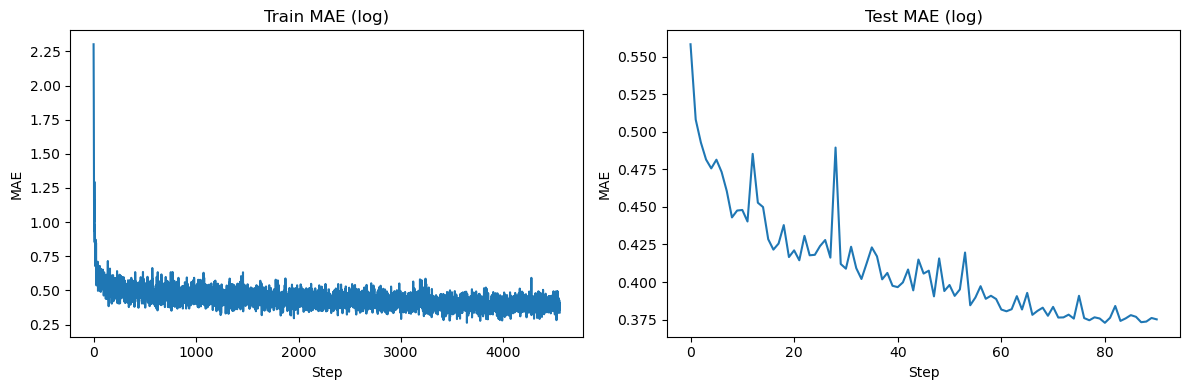

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [12:38<00:00, 75.88s/it]


In [36]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
img_head = EmbeddingRegressor().to(DEVICE)
img_head = train_embed_model(img_head, train_img_dl, test_img_dl)

In [39]:
torch.save(img_head.state_dict(), "weights/img_embedding_regressor.pt")

ПРЕДИКТЫ ДЛЯ ОБУЧЕНИЯ

In [52]:
preds_list = []
img_head.eval()
test_img_dl = DataLoader(test_img_ds, batch_size=32, shuffle=False)
with torch.no_grad():
    for x, _ in test_img_dl:
        x = x.to(DEVICE)
        preds_list.append(img_head(x).detach().cpu().numpy())

np.save("preds_for_train/img_model_preds.npy", np.concatenate(preds_list, axis=0))

ПРЕДИКТЫ ДЛЯ ИНФЕРЕНСА

In [71]:
X_img_inf = np.load("embeddings_for_inference/image_embeddings.npy")
assert X_img_inf.shape[0] == len(test_df)
img_inf_ds = EmbeddingsDataset(X_img_inf, mode='predict')
img_inf_dl = DataLoader(img_inf_ds, batch_size=32, shuffle=False)
preds_list = []
with torch.no_grad():
    for x in img_inf_dl:
        x = x.to(DEVICE)
        preds_list.append(img_head(x).detach().cpu().numpy())

np.save("preds_for_inference/img_model_preds.npy", np.concatenate(preds_list, axis=0))

__ТЕКСТЫ__

Обучение предсказывающей головы:

In [57]:
class TextEmbRegressor(nn.Module):
    def __init__(self, in_dim=384, p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, 4)
        )
    def forward(self, x):
        return self.net(x)

In [58]:
targets = ['real_weight', 'real_height', 'real_length', 'real_width']
X_embed = np.load("embeddings/e5s_text_embeds.npy")
X_text_train, X_text_test = X_embed[idx_train], X_embed[idx_test]
y_train = np.array(train_df.iloc[idx_train][targets])
y_test = np.array(train_df.iloc[idx_test][targets])

assert X_text_train.shape[0] == y_train.shape[0]
assert X_text_test.shape[0] == y_test.shape[0]

In [59]:
train_text_ds = EmbeddingsDataset(X_text_train, y_train, 'fit')
test_text_ds = EmbeddingsDataset(X_text_test, y_test, 'fit')

train_text_dl = DataLoader(train_text_ds, batch_size=32, shuffle=True)
test_text_dl = DataLoader(test_text_ds, batch_size=32, shuffle=True)

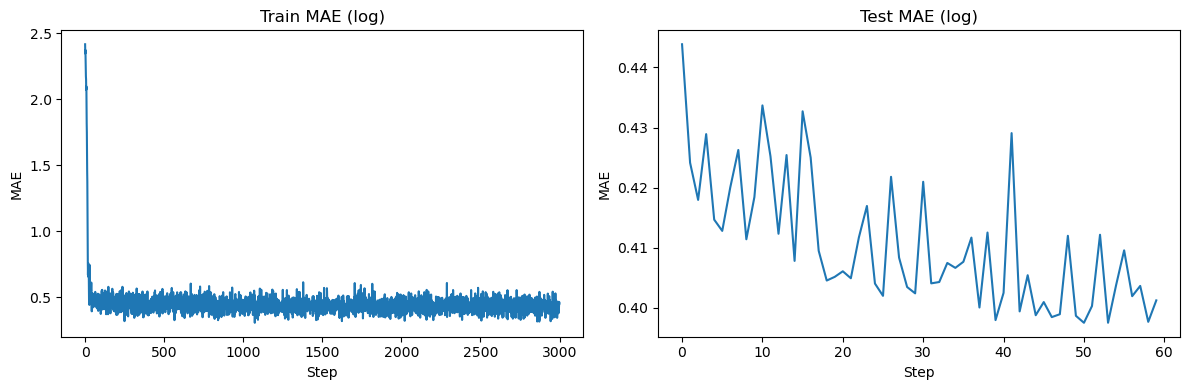

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [06:42<00:00, 40.28s/it]


In [62]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
text_head = TextEmbRegressor().to(DEVICE)
text_head = train_embed_model(text_head, train_text_dl, test_text_dl, toler = 20)

Предикты для обучения:

In [69]:
preds_list = []
text_head.eval()
test_text_dl = DataLoader(test_text_ds, batch_size=32, shuffle=False)
with torch.no_grad():
    for x, _ in test_text_dl:
        x = x.to(DEVICE)
        preds_list.append(text_head(x).detach().cpu().numpy())

np.save("preds_for_train/text_model_preds.npy", np.concatenate(preds_list, axis=0))

Предикты для инференса:

In [70]:
X_text_inf = np.load("embeddings_for_inference/e5small_text_embeds.npy")
assert X_text_inf.shape[0] == len(test_df)
text_inf_ds = EmbeddingsDataset(X_text_inf, mode='predict')
text_inf_dl = DataLoader(text_inf_ds, batch_size=32, shuffle=False)
preds_list = []
with torch.no_grad():
    for x in text_inf_dl:
        x = x.to(DEVICE)
        preds_list.append(text_head(x).detach().cpu().numpy())

np.save("preds_for_inference/text_model_preds.npy", np.concatenate(preds_list, axis=0))

__ОСТАЛОСЬ ОБУЧИТЬ ФИНАЛЬНУЮ ГОЛОВУ!!!__

In [91]:
boost_train = pd.read_csv("preds_for_train/boosting_predictions.csv")
text_train = pd.DataFrame(np.load("preds_for_train/text_model_preds.npy"))
img_train = pd.DataFrame(np.load("preds_for_train/img_model_preds.npy"))

boost_test = pd.read_csv("preds_for_inference/boosting_predictions.csv")
text_test = pd.DataFrame(np.load("preds_for_inference/text_model_preds.npy"))
img_test = pd.DataFrame(np.load("preds_for_inference/img_model_preds.npy"))

In [92]:
assert (len(boost_train) == len(text_train)) & (len(text_train) == len(img_train))
assert (len(boost_test) == len(text_test)) & (len(text_test) == len(img_test))

In [93]:
X_train = pd.concat([boost_train, text_train, img_train], axis=1)
# X_train['subcat_name'] = list(train_df.iloc[idx_test]['subcategory_name'])
X_train['subcat_name'] = list(train_df.iloc[idx_test]['category_name'])
y_train = y_test # то, что было раньше тестом, теперь трейн
X_inf = pd.concat([boost_test, text_test, img_test], axis=1)
# X_inf['subcat_name'] = list(test_df['subcategory_name'])
X_inf['subcat_name'] = list(test_df['category_name'])

In [94]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
ohe.fit(X_train[["subcat_name"]])

train_ohe = ohe.transform(X_train[["subcat_name"]])
inf_ohe = ohe.transform(X_inf[["subcat_name"]])

train_ohe_df = pd.DataFrame(train_ohe)
inf_ohe_df = pd.DataFrame(inf_ohe)

X_train = pd.concat([X_train.drop(columns=["subcat_name"]), train_ohe_df], axis=1)
X_inf = pd.concat([X_inf.drop(columns=["subcat_name"]),   inf_ohe_df], axis=1)

In [95]:
assert X_train.shape[1] == X_inf.shape[1]
X_train.shape[1]

371

In [96]:
class RegressorHead(nn.Module):
    def __init__(self, p = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(32, 4),
        )

    def forward(self, x):
        return self.net(x)

In [97]:
class HeadDataset(Dataset):
    def __init__(self, X, y = None):
        self.X = X.astype(np.float32)
        if y is not None:
            self.y = y.astype(np.float32)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(np.log1p(self.y[idx]), dtype=torch.float32)
        return torch.tensor(self.X[idx], dtype=torch.float32)

In [98]:
X_full = np.array(X_train)
y_full = np.array(y_train)

X_tr, X_tst, y_tr, y_tst = train_test_split(X_full, y_full,test_size=0.2,random_state=42,shuffle=True)

train_ds = HeadDataset(X_tr, y_tr)
test_ds = HeadDataset(X_tst, y_tst)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False)

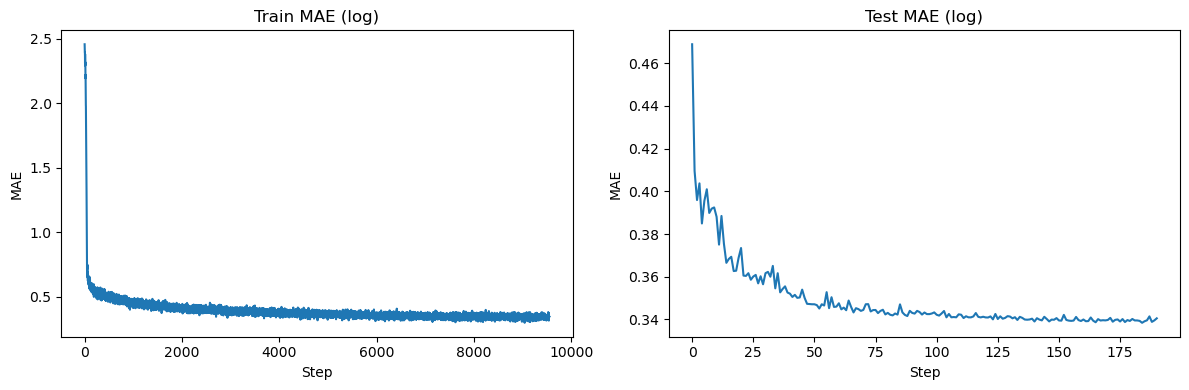

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [12:24<00:00, 14.89s/it]


In [99]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
regr_head = RegressorHead().to(DEVICE)
regr_head = train_embed_model(regr_head, train_dl, test_dl, toler = 75, ep = 50)

__INFERENCE!!!!!!__

In [106]:
X_inf = np.array(X_inf)
inf_ds = HeadDataset(X_inf)
inf_dl = DataLoader(inf_ds, batch_size=256, shuffle=False)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
regr_head.eval()
preds = []
with torch.no_grad():
    for x in inf_dl:
        x = x.to(DEVICE)
        p = regr_head(x).cpu().numpy()
        preds.append(p)

preds = np.expm1(np.vstack(preds))
result = pd.DataFrame({
    "item_id": test_item_id,
    "weight": preds[:, 0].astype(float),
    "height": preds[:, 1].astype(float),
    "length": preds[:, 2].astype(float),
    "width": preds[:, 3].astype(float),
})
result.to_csv("predictions/full_model_predictions.csv", index=False)

Получил на степике 0.331891!!! Но вообще есть ощущение, что модель использует только микрокатегорию, попробуем заменить на субкатегорию.

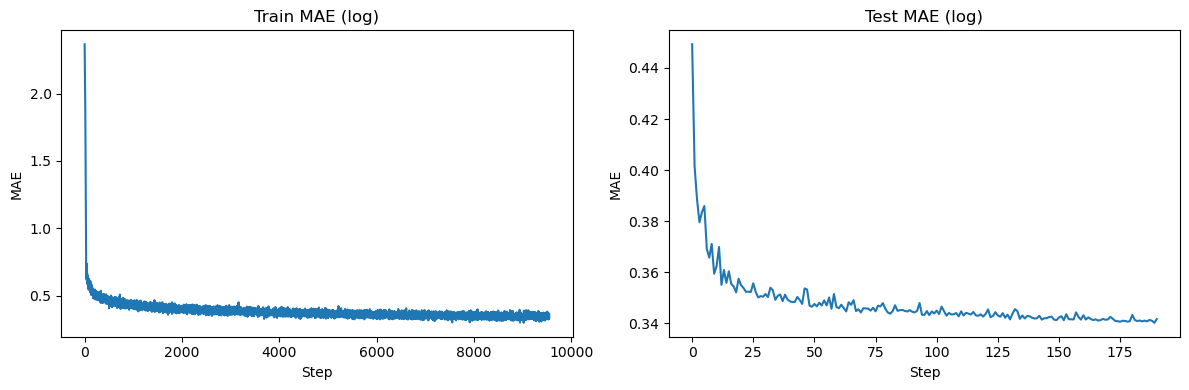

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [11:28<00:00, 13.76s/it]


In [107]:
boost_train = pd.read_csv("preds_for_train/boosting_predictions.csv")
text_train = pd.DataFrame(np.load("preds_for_train/text_model_preds.npy"))
img_train = pd.DataFrame(np.load("preds_for_train/img_model_preds.npy"))

boost_test = pd.read_csv("preds_for_inference/boosting_predictions.csv")
text_test = pd.DataFrame(np.load("preds_for_inference/text_model_preds.npy"))
img_test = pd.DataFrame(np.load("preds_for_inference/img_model_preds.npy"))
assert (len(boost_train) == len(text_train)) & (len(text_train) == len(img_train))
assert (len(boost_test) == len(text_test)) & (len(text_test) == len(img_test))

X_train = pd.concat([boost_train, text_train, img_train], axis=1)
X_train['subcat_name'] = list(train_df.iloc[idx_test]['subcategory_name'])
y_train = y_test # то, что было раньше тестом, теперь трейн
X_inf = pd.concat([boost_test, text_test, img_test], axis=1)
X_inf['subcat_name'] = list(test_df['subcategory_name'])

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
ohe.fit(X_train[["subcat_name"]])

train_ohe = ohe.transform(X_train[["subcat_name"]])
inf_ohe = ohe.transform(X_inf[["subcat_name"]])

train_ohe_df = pd.DataFrame(train_ohe)
inf_ohe_df = pd.DataFrame(inf_ohe)

X_train = pd.concat([X_train.drop(columns=["subcat_name"]), train_ohe_df], axis=1)
X_inf = pd.concat([X_inf.drop(columns=["subcat_name"]),   inf_ohe_df], axis=1)

assert X_train.shape[1] == X_inf.shape[1]
X_train.shape[1]

X_full = np.array(X_train)
y_full = np.array(y_train)

X_tr, X_tst, y_tr, y_tst = train_test_split(X_full, y_full,test_size=0.2,random_state=42,shuffle=True)

train_ds = HeadDataset(X_tr, y_tr)
test_ds = HeadDataset(X_tst, y_tst)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
regr_head = RegressorHead().to(DEVICE)
regr_head = train_embed_model(regr_head, train_dl, test_dl, toler = 75, ep = 50)

In [108]:
X_inf = np.array(X_inf)
inf_ds = HeadDataset(X_inf)
inf_dl = DataLoader(inf_ds, batch_size=256, shuffle=False)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
regr_head.eval()
preds = []
with torch.no_grad():
    for x in inf_dl:
        x = x.to(DEVICE)
        p = regr_head(x).cpu().numpy()
        preds.append(p)

preds = np.expm1(np.vstack(preds))
result = pd.DataFrame({
    "item_id": test_item_id,
    "weight": preds[:, 0].astype(float),
    "height": preds[:, 1].astype(float),
    "length": preds[:, 2].astype(float),
    "width": preds[:, 3].astype(float),
})
result.to_csv("predictions/full_model_subcat_predictions.csv", index=False)

In [109]:
X_train.shape[1]

37

На степике 0.332753. Получилось немного хуже, чем в прошлый раз, но все еще лучше, чем обычный катбуст.

Я хотел еще посмотреть permutation importance, но уже не успеваю сам его написать, поэтому попросил гпт его написать:

In [114]:
import numpy as np
import torch
import torch.nn as nn

def eval_mae(model, X, y):
    DEVICE = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, len(X), 1024):
            xb = torch.from_numpy(X[i:i+1024]).float().to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    preds = np.vstack(preds)
    return np.mean(np.abs(preds - y))

base_mae = eval_mae(regr_head, X_tst, y_tst)

importances = []
for j in range(X_tst.shape[1]):
    X_perm = X_tst.copy()
    np.random.shuffle(X_perm[:, j])   # перемешиваем 1 признак
    mae = eval_mae(regr_head, X_perm, y_tst)
    importances.append(mae - base_mae)

importances = np.array(importances)
importances

array([ 2.55111361e-02, -4.29554424e-03,  2.74666416e-03,  3.45152594e-03,
        1.82887565e-03, -3.95362289e-04, -1.14709906e-04,  4.75194993e-04,
        2.06529749e-02, -6.76669089e-03, -2.42030232e-03,  2.50090831e-03,
       -8.42807979e-04, -1.60539461e-03, -4.01971860e-05, -2.30108687e-03,
       -3.24194819e-03, -2.19576978e-04, -3.87837044e-03, -2.10528765e-04,
       -7.77269661e-04, -4.36491090e-04, -3.26197699e-05, -2.00049500e-04,
       -1.42382234e-03, -5.61029331e-03, -4.33144254e-04, -1.13338596e-04,
       -7.92979561e-05, -6.42103977e-04, -1.89401400e-03, -9.36379904e-04,
        2.12150523e-04, -2.44605278e-04, -1.14231094e-03, -2.23290017e-04,
        4.99102537e-05])

In [117]:
np.argsort(importances)[::-1]

array([ 0,  8,  3,  2, 11,  4,  7, 32, 36, 22, 14, 28, 27,  6, 23, 19, 17,
       35, 33,  5, 26, 21, 29, 20, 12, 31, 34, 24, 13, 30, 15, 10, 16, 18,
        1, 25,  9], dtype=int64)

In [118]:
np.sort(importances)[::-1]

array([ 2.55111361e-02,  2.06529749e-02,  3.45152594e-03,  2.74666416e-03,
        2.50090831e-03,  1.82887565e-03,  4.75194993e-04,  2.12150523e-04,
        4.99102537e-05, -3.26197699e-05, -4.01971860e-05, -7.92979561e-05,
       -1.13338596e-04, -1.14709906e-04, -2.00049500e-04, -2.10528765e-04,
       -2.19576978e-04, -2.23290017e-04, -2.44605278e-04, -3.95362289e-04,
       -4.33144254e-04, -4.36491090e-04, -6.42103977e-04, -7.77269661e-04,
       -8.42807979e-04, -9.36379904e-04, -1.14231094e-03, -1.42382234e-03,
       -1.60539461e-03, -1.89401400e-03, -2.30108687e-03, -2.42030232e-03,
       -3.24194819e-03, -3.87837044e-03, -4.29554424e-03, -5.61029331e-03,
       -6.76669089e-03])

Как мы видим, первые два значения (они соответствуют базовым моделям), на порядок больше следующих, т.е. все таки моя модель больше опирается на выходы базовых моделей.

Еще мне интересно на структуру ошибки MAE по каждому из таргетов, снова код от гпт:

In [119]:
import torch
import numpy as np

def eval_mae_per_target(model, dataloader):
    DEVICE = next(model.parameters()).device
    model.eval()

    preds_all = []
    y_all = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x)

            preds_all.append(pred.cpu().numpy())
            y_all.append(y.cpu().numpy())

    preds_all = np.vstack(preds_all)  # (N,4)
    y_all = np.vstack(y_all)          # (N,4)

    mae_per_target = np.mean(np.abs(preds_all - y_all), axis=0)

    return mae_per_target

mae_targets = eval_mae_per_target(regr_head, test_dl)

target_names = ["weight", "length", "width", "height"]  # проверь порядок!
for name, val in zip(target_names, mae_targets):
    print(f"{name}: MAE = {val:.6f} (log1p)")

weight: MAE = 0.270940 (log1p)
length: MAE = 0.505542 (log1p)
width: MAE = 0.290510 (log1p)
height: MAE = 0.299675 (log1p)


Видим, что наибольшая ошибка в длине. Но возможно, дело в том, что там и значения просто на порядок больше:

In [121]:
train_df[targets].describe()

,real_weight,real_height,real_length,real_width
count,305474.000000,305474.000000,305474.000000,305474.000000
mean,1.601118,11.718133,32.855189,23.643338
std,13.135710,8.315487,16.382295,10.651616
min,0.051000,1.000000,2.000000,2.000000
25%,0.360000,6.000000,23.000000,16.000000
50%,0.700000,10.000000,32.000000,22.000000
75%,1.500000,15.000000,40.000000,30.000000
max,7090.000000,135.000000,300.000000,165.000000


Да, так и оказалось, но все таки длина не прям на порядок больше чем real_width, а MAE у нее сильно хуже. Возможно надо либо лучше подчистить данные, либо как то доработать модель, например предсказать сначала все кроме длины, а потом эти значения подать на вход для нейросети предсказывающей длину.